In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

np.set_printoptions(suppress=True)

import os
import scanpy as sc
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

In [2]:
adata = sc.read_h5ad('../datasets/Mouse_Hematopoiesis/adata_used.h5ad')
adata

AnnData object with n_obs × n_vars = 44756 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
adata.var_names_make_unique()
adata = adata[adata.obs['meta_clones'] != '-1.0', :]
idx_mt = [not gene.startswith('mt-') for gene in adata.var.index]
adata = adata[:, idx_mt]
adata

View of AnnData object with n_obs × n_vars = 44756 × 4995
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
adata_hsc = adata[adata.obs['label_man'] == 'prog_2', :]
adata_hsc.shape

(5759, 4995)

In [5]:
test = adata_hsc[adata_hsc.obs['meta_clones'].values == str(1), :].copy()
refe = adata_hsc[adata_hsc.obs['meta_clones'].values == str(0), :].copy()

/tmp/ipykernel_2768590/1698310146.py:6: RuntimeWarning: divide by zero encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2768590/1698310146.py:6: RuntimeWarning: invalid value encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2768590/1698310146.py:7: RuntimeWarning: divide by zero encountered in log2
  lfc = np.array(np.log2(fold_change)).squeeze()


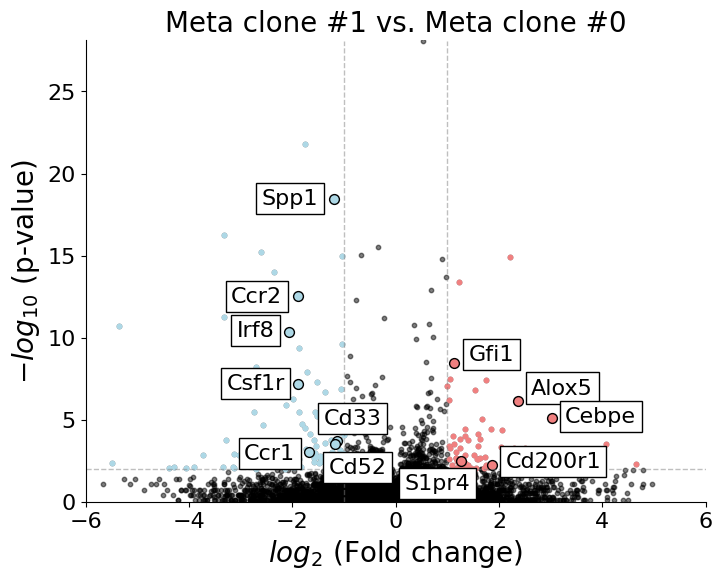

In [6]:
from scipy import stats

mean_test = np.mean(np.exp(test.raw.X.todense()) - 1, axis=0)
mean_refe = np.mean(np.exp(refe.raw.X.todense()) - 1, axis=0)

fold_change = mean_test / mean_refe
lfc = np.array(np.log2(fold_change)).squeeze()

t_statistic, p_values = stats.mannwhitneyu(test.raw.X.todense(), refe.raw.X.todense())
neg_log_10 = -np.log10(p_values)
threshold = 0.01

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
plt.hlines(y=-np.log10(0.01), linestyles='dashed', xmin=-6, xmax=6, color='grey', alpha=0.5, linewidth=1)
plt.scatter(lfc, neg_log_10, color='black', alpha=0.5, s=10)
plt.xlim([-6, 6])
plt.ylim([0, np.nanmax(neg_log_10) + 0.1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.vlines(x=-1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', alpha=0.5, linewidth=1)
plt.vlines(x=1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', linewidth=1, alpha=0.5)
plt.scatter(lfc[np.bitwise_and(lfc > 1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc > 1, p_values < threshold)], color='lightcoral', s=10)
plt.scatter(lfc[np.bitwise_and(lfc < -1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc < -1, p_values < threshold)], color='lightblue', s=10)


index = [2507, 4351, 4585, 8053, 20087]
names = ['Alox5', 'Cd200r1', 'Cebpe', 'Gfi1', 'S1pr4']

for i in range(5):
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightcoral',edgecolors='k', s=50)

index = [4310, 4313, 4387, 4404, 5405, 13168, 21536]
names = ['Ccr1', 'Ccr2', 'Cd33', 'Cd52', 'Csf1r', 'Irf8', 'Spp1']

for i in range(7):
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightblue',edgecolors='k', s=50)

t = plt.text(lfc[2507] + 0.25, neg_log_10[2507] + 0.45, 'Alox5', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4351] + 0.25, neg_log_10[4351] -0.15 , 'Cd200r1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4585] + 0.25, neg_log_10[4585] -0.25 , 'Cebpe', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[8053] +0.3, neg_log_10[8053]+0.2 , 'Gfi1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[20087] -1.1, neg_log_10[20087]-1.7 , 'S1pr4', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

###

t = plt.text(lfc[4310] - 1.25, neg_log_10[4310] - 0.5, 'Ccr1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4313] - 1.3, neg_log_10[4313] - .4, 'Ccr2', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4387] - .25, neg_log_10[4387] + 1, 'Cd33', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4404] - 0.12, neg_log_10[4404] -1.8, 'Cd52', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[5405] - 1.39, neg_log_10[5405] -0.3, 'Csf1r', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[13168] - 1, neg_log_10[13168] -0.3, 'Irf8', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[21536] - 1.4, neg_log_10[21536] -0.3, 'Spp1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

plt.xlabel('$log_{2}$ (Fold change)', fontsize=20)
plt.grid(False)
plt.ylabel('$-log_{10}$ (p-value)', fontsize=20)
plt.title('Meta clone #1 vs. Meta clone #0', fontsize=20)

plt.savefig('./de_mouse_0_vs_1_new_prog2.svg', bbox_inches='tight', transparent=True, dpi=300)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWa

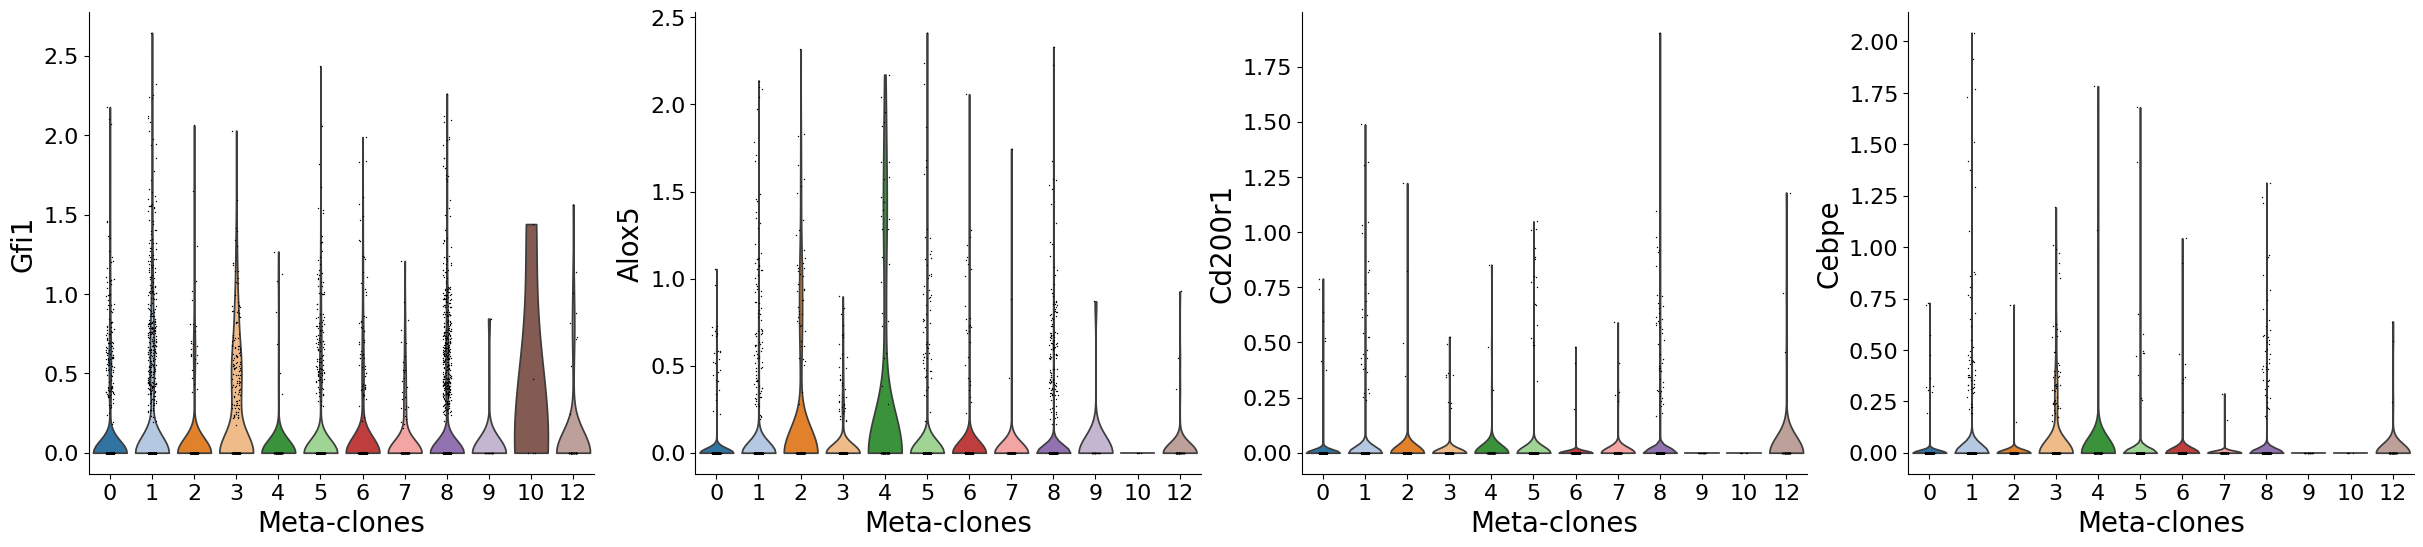

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(30, 6))
names = ['Gfi1', 'Alox5', 'Cd200r1', 'Cebpe']

for idx, gene in enumerate(names):
    sc.pl.violin(adata_hsc, gene, groupby='meta_clones', ax=axes[idx], show=False, palette='tab20')
    axes[idx].set_xlabel('Meta-clones')
    axes[idx].yaxis.grid(False)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    axes[idx].set_xlabel('Meta-clones', fontsize=20)  # Adjust fontsize as needed
    axes[idx].set_ylabel(gene, fontsize=20)  # You can set y-label if needed
    
    axes[idx].tick_params(axis='x', labelsize=16)  # Adjust x-tick font size
    axes[idx].tick_params(axis='y', labelsize=16)  


plt.savefig('violin_nicola_prog2_mc1_vs_mc0_new.svg', bbox_inches='tight', transparent=True, dpi=300)